### Leverage strategy

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
import datetime as dt

# Set print options
np.set_printoptions(precision = 3)

pd.options.display.max_rows = 4
pd.options.mode.copy_on_write = True
pd.set_option('display.float_format', '{:,.2f}'.format)

import warnings
warnings.filterwarnings("ignore")

In [26]:
# all params
start_date = '2019-01-10'
end_date = '2025-01-10'

short_window = 50
middle_window = 100
long_window = 200

trans_fees = 1
initial_capital = 100000

In [27]:
stock_df = yf.download(["QQQ", "TQQQ"], start_date, end_date)['Adj Close']
stock_df.columns = ['S_PRICE', 'LS_PRICE']
stock_df

[*********************100%%**********************]  2 of 2 completed


,S_PRICE,LS_PRICE
Date,,
2019-01-10,155.14,10.12
2019-01-11,154.57,10.00
...,...,...
2025-01-07,515.18,80.62
2025-01-08,515.27,80.68


In [28]:
stock_df['SHORT_DMA'] = stock_df['S_PRICE'].rolling(window=short_window).mean()
stock_df['MID_DMA'] = stock_df['S_PRICE'].rolling(window=middle_window).mean()
stock_df['LONG_DMA'] = stock_df['S_PRICE'].rolling(window=long_window).mean()

stock_df = stock_df.dropna()

stock_df['S_UNITS'] = 0
stock_df['LS_UNITS'] = 0
stock_df['S_VALUE'] = 0
stock_df['LS_VALUE'] = 0
stock_df['PORT_VALUE'] = 0

stock_df['STATE'] = -1
stock_df['REMARKS'] = 'None'
stock_df

,S_PRICE,LS_PRICE,SHORT_DMA,MID_DMA,LONG_DMA,S_UNITS,LS_UNITS,S_VALUE,LS_VALUE,PORT_VALUE,STATE,REMARKS
Date,,,,,,,,,,,,
2019-10-24,187.83,15.99,183.00,182.29,176.31,0,0,0,0,0,-1,None
2019-10-25,189.33,16.35,183.26,182.48,176.48,0,0,0,0,0,-1,None
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-07,515.18,80.62,511.74,495.35,475.07,0,0,0,0,0,-1,None
2025-01-08,515.27,80.68,512.16,495.77,475.42,0,0,0,0,0,-1,None


In [29]:
# start of strategy
strat_sdate = stock_df.index[0]
print(f"strat_sdate: {strat_sdate}")

strat_edate = stock_df.index[len(stock_df)-1]
print(f"strat_edate: {strat_edate}")

stock_df.loc[strat_sdate, 'S_VALUE'] = initial_capital - trans_fees
stock_df.loc[strat_sdate, 'S_UNITS'] = stock_df.loc[strat_sdate, 'S_VALUE'] \
                            / stock_df.loc[strat_sdate, 'S_PRICE']

stock_df.loc[strat_sdate, 'PORT_VALUE'] = stock_df.loc[strat_sdate, 'S_VALUE'] \
                            + stock_df.loc[strat_sdate, 'LS_VALUE']
stock_df.loc[strat_sdate, 'STATE'] = 0
stock_df

strat_sdate: 2019-10-24 00:00:00
strat_edate: 2025-01-08 00:00:00


,S_PRICE,LS_PRICE,SHORT_DMA,MID_DMA,LONG_DMA,S_UNITS,LS_UNITS,S_VALUE,LS_VALUE,PORT_VALUE,STATE,REMARKS
Date,,,,,,,,,,,,
2019-10-24,187.83,15.99,183.00,182.29,176.31,532.40,0,99999,0,99999,0,None
2019-10-25,189.33,16.35,183.26,182.48,176.48,0.00,0,0,0,0,-1,None
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-07,515.18,80.62,511.74,495.35,475.07,0.00,0,0,0,0,-1,None
2025-01-08,515.27,80.68,512.16,495.77,475.42,0.00,0,0,0,0,-1,None


In [30]:
def rebalance(sell_ticker, buy_ticker, redist_pct, today, yesterday):
    cash = stock_df.loc[yesterday, sell_ticker + '_UNITS'] \
        * redist_pct * stock_df.loc[today, sell_ticker + '_PRICE']
    stock_df.loc[today, buy_ticker + '_UNITS'] = stock_df.loc[yesterday, buy_ticker + '_UNITS'] \
        + (cash - 2 * trans_fees) / stock_df.loc[today, buy_ticker + '_PRICE']
    stock_df.loc[today, sell_ticker + '_UNITS'] = \
        stock_df.loc[yesterday, sell_ticker + '_UNITS'] * (1 - redist_pct)

    stock_df.loc[today, sell_ticker + '_VALUE'] = \
        stock_df.loc[today, sell_ticker + '_UNITS'] \
            * stock_df.loc[today, sell_ticker + '_PRICE']
    stock_df.loc[today, buy_ticker + '_VALUE'] = \
        stock_df.loc[today, buy_ticker + '_UNITS'] \
            * stock_df.loc[today, buy_ticker + '_PRICE']
    
    stock_df.loc[today, 'PORT_VALUE'] = stock_df.loc[today, buy_ticker + '_VALUE'] \
                            + stock_df.loc[today, sell_ticker + '_VALUE']

In [31]:
def no_rebalance(sell_ticker, buy_ticker, today, yesterday):
    stock_df.loc[today, buy_ticker + '_UNITS'] = stock_df.loc[yesterday, buy_ticker + '_UNITS']
    stock_df.loc[today, sell_ticker + '_UNITS'] = stock_df.loc[yesterday, sell_ticker + '_UNITS']

    stock_df.loc[today, sell_ticker + '_VALUE'] = \
        stock_df.loc[today, sell_ticker + '_UNITS'] \
            * stock_df.loc[today, sell_ticker + '_PRICE']
    stock_df.loc[today, buy_ticker + '_VALUE'] = \
        stock_df.loc[today, buy_ticker + '_UNITS'] \
            * stock_df.loc[today, buy_ticker + '_PRICE']
    
    stock_df.loc[today, 'PORT_VALUE'] = stock_df.loc[today, buy_ticker + '_VALUE'] \
                            + stock_df.loc[today, sell_ticker + '_VALUE']

#### PORTFOLIO STATES:
    State-0: 50 DMA <= stock price
    State-1: 100DMA <= stock price < 50DMA
    State-2: 200DMA <= stock price < 100DMA
    State-3:           stock price < 200DMA


In [32]:
# More params
short_dma_cross_down_redist = 0.3
mid_dma_cross_down_redist = 0.43
long_dma_cross_down_redist = 1

short_dma_cross_up_redist = 1
mid_dma_cross_up_redist = 0.5
long_dma_cross_up_redist = 0.4

# Special case
mid_dma_cross_down_from0_redist = 0.6

In [33]:
yesterday = strat_sdate
prev_state = stock_df.loc[strat_sdate, 'STATE']

for row in stock_df.iloc[1:].itertuples():
    #print(f"Processing date: {row.Index}")
    today = row.Index
    if stock_df.loc[today, 'S_PRICE'] < stock_df.loc[today, 'LONG_DMA']:
        if prev_state == 3:
            no_rebalance('S', 'LS', today, yesterday)
            #print(f"Current state: {prev_state}")
            stock_df.loc[today, 'REMARKS'] = f"Current state: {prev_state}"
        else:
            #print(f"Went below LONG_DMA on date: {today}")
            stock_df.loc[today, 'REMARKS'] = 'Went below LONG_DMA'

            # Move everything to Leveraged Stock
            rebalance('S', 'LS', long_dma_cross_down_redist, today, yesterday)
        stock_df.loc[today, 'STATE'] = 3

    elif stock_df.loc[today, 'S_PRICE'] < stock_df.loc[today, 'MID_DMA']:
        if prev_state == 2:
            no_rebalance('S', 'LS', today, yesterday)
            #print(f"Current state: {prev_state}")
            stock_df.loc[today, 'REMARKS'] = f"Current state: {prev_state}"
        elif prev_state == 0:
            #print(f"Went below MID_DMA from state-0 on date: {today}")
            stock_df.loc[today, 'REMARKS'] = 'Went below MID_DMA from state-0'

            # Sell 60% of Stock and buy Leveraged Stock
            rebalance('S', 'LS', mid_dma_cross_down_from0_redist, today, yesterday)
        elif prev_state == 1:
            #print(f"Went below MID_DMA on date: {today}")
            stock_df.loc[today, 'REMARKS'] = 'Went below MID_DMA'

            # Sell 30% of Stock and buy Leveraged Stock
            rebalance('S', 'LS', mid_dma_cross_down_redist, today, yesterday)
        elif prev_state == 3:
            #print(f"Went above LONG_DMA on date: {today}")
            stock_df.loc[today, 'REMARKS'] = 'Went above LONG_DMA'

            # Sell 40% of Leveraged Stock and buy Stock
            rebalance('LS', 'S', long_dma_cross_up_redist, today, yesterday)
        stock_df.loc[today, 'STATE'] = 2

    elif stock_df.loc[today, 'S_PRICE'] < stock_df.loc[today, 'SHORT_DMA']:
        if prev_state == 1:
            no_rebalance('S', 'LS', today, yesterday)
            #print(f"Current state: {prev_state}")
            stock_df.loc[today, 'REMARKS'] = f"Current state: {prev_state}"
        elif prev_state == 0:
            #print(f"Went below SHORT_DMA on date: {today}")
            stock_df.loc[today, 'REMARKS'] = 'Went below SHORT_DMA'

            # Sell 30% of Stock and buy Leveraged Stock
            rebalance('S', 'LS', short_dma_cross_down_redist, today, yesterday)
        elif prev_state == 2:
            #print(f"Went above MID_DMA on date: {today}")
            stock_df.loc[today, 'REMARKS'] = 'Went above MID_DMA'

            # Sell 30% of Leveraged Stock and buy Stock
            rebalance('LS', 'S', mid_dma_cross_up_redist, today, yesterday)
        else:
            no_rebalance('S', 'LS', today, yesterday)
            print(f"Invalid transition to state-1 from state-{prev_state} on date {today}")
        stock_df.loc[today, 'STATE'] = 1
    else:
        if prev_state == 0:
            no_rebalance('S', 'LS', today, yesterday)
            #print(f"Current state: {prev_state}")
            stock_df.loc[today, 'REMARKS'] = f"Current state: {prev_state}"
        else:
            #print(f"Went above SHORT_DMA on date: {today}")
            stock_df.loc[today, 'REMARKS'] = 'Went above SHORT_DMA'

            # Move everything to non-leveraged Stock
            rebalance('LS', 'S', short_dma_cross_up_redist, today, yesterday)
        stock_df.loc[today, 'STATE'] = 0

    prev_state = stock_df.loc[today, 'STATE']
    yesterday = today

In [34]:
stock_df

,S_PRICE,LS_PRICE,SHORT_DMA,MID_DMA,LONG_DMA,S_UNITS,LS_UNITS,S_VALUE,LS_VALUE,PORT_VALUE,STATE,REMARKS
Date,,,,,,,,,,,,
2019-10-24,187.83,15.99,183.00,182.29,176.31,532.40,0.00,"99,999.00",0.00,"99,999.00",0,None
2019-10-25,189.33,16.35,183.26,182.48,176.48,532.40,0.00,"100,797.60",0.00,"100,797.60",0,Current state: 0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-07,515.18,80.62,511.74,495.35,475.07,365.23,0.00,"188,159.50",0.00,"188,159.50",0,Current state: 0
2025-01-08,515.27,80.68,512.16,495.77,475.42,365.23,0.00,"188,192.38",0.00,"188,192.38",0,Current state: 0


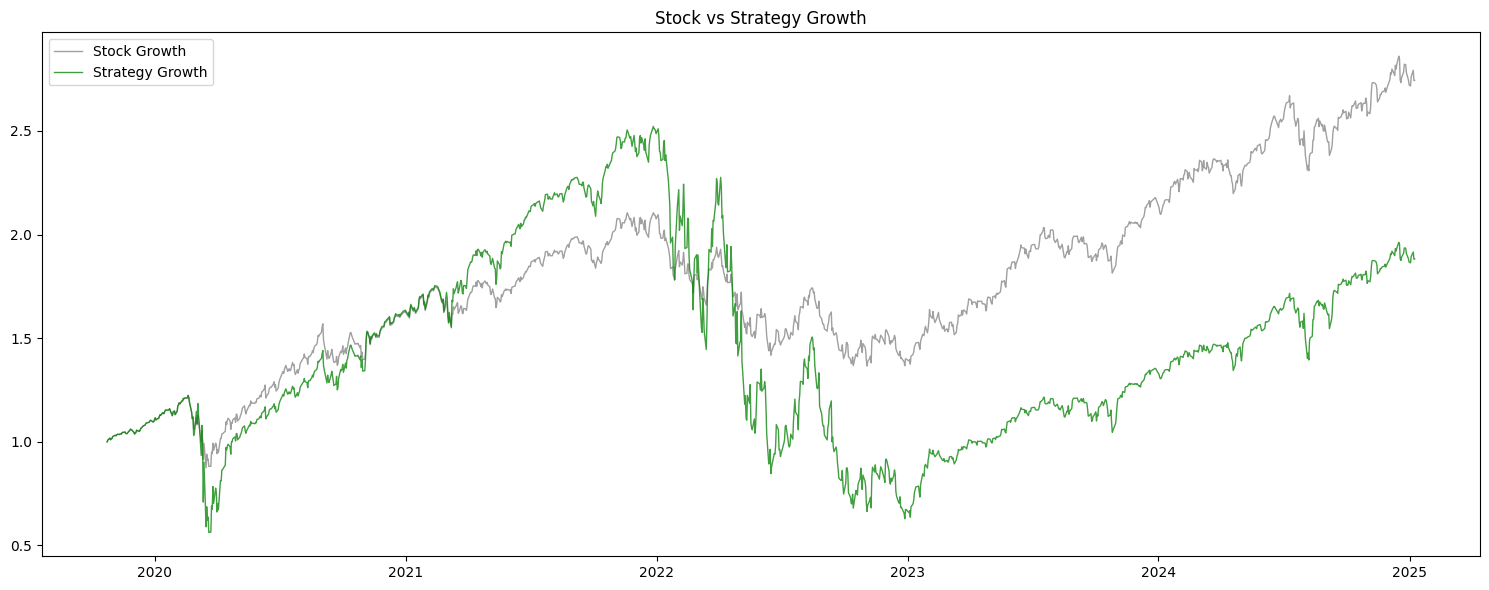

In [35]:
stock_df['S_GROWTH'] = stock_df['S_PRICE'] / stock_df.loc[strat_sdate, 'S_PRICE']
stock_df['STRAT_GROWTH'] = stock_df['PORT_VALUE'] / stock_df.loc[strat_sdate, 'PORT_VALUE']

fig_size = (15, 6)
plt.figure(figsize=fig_size)

plt.plot(stock_df.index, stock_df['S_GROWTH'], label='Stock Growth', color="grey", alpha=0.75, lw=1)
plt.plot(stock_df.index, stock_df['STRAT_GROWTH'], label='Strategy Growth', color="green", alpha=0.75, lw=1)

plt.legend()
plt.title("Stock vs Strategy Growth")
plt.tight_layout()
plt.show()

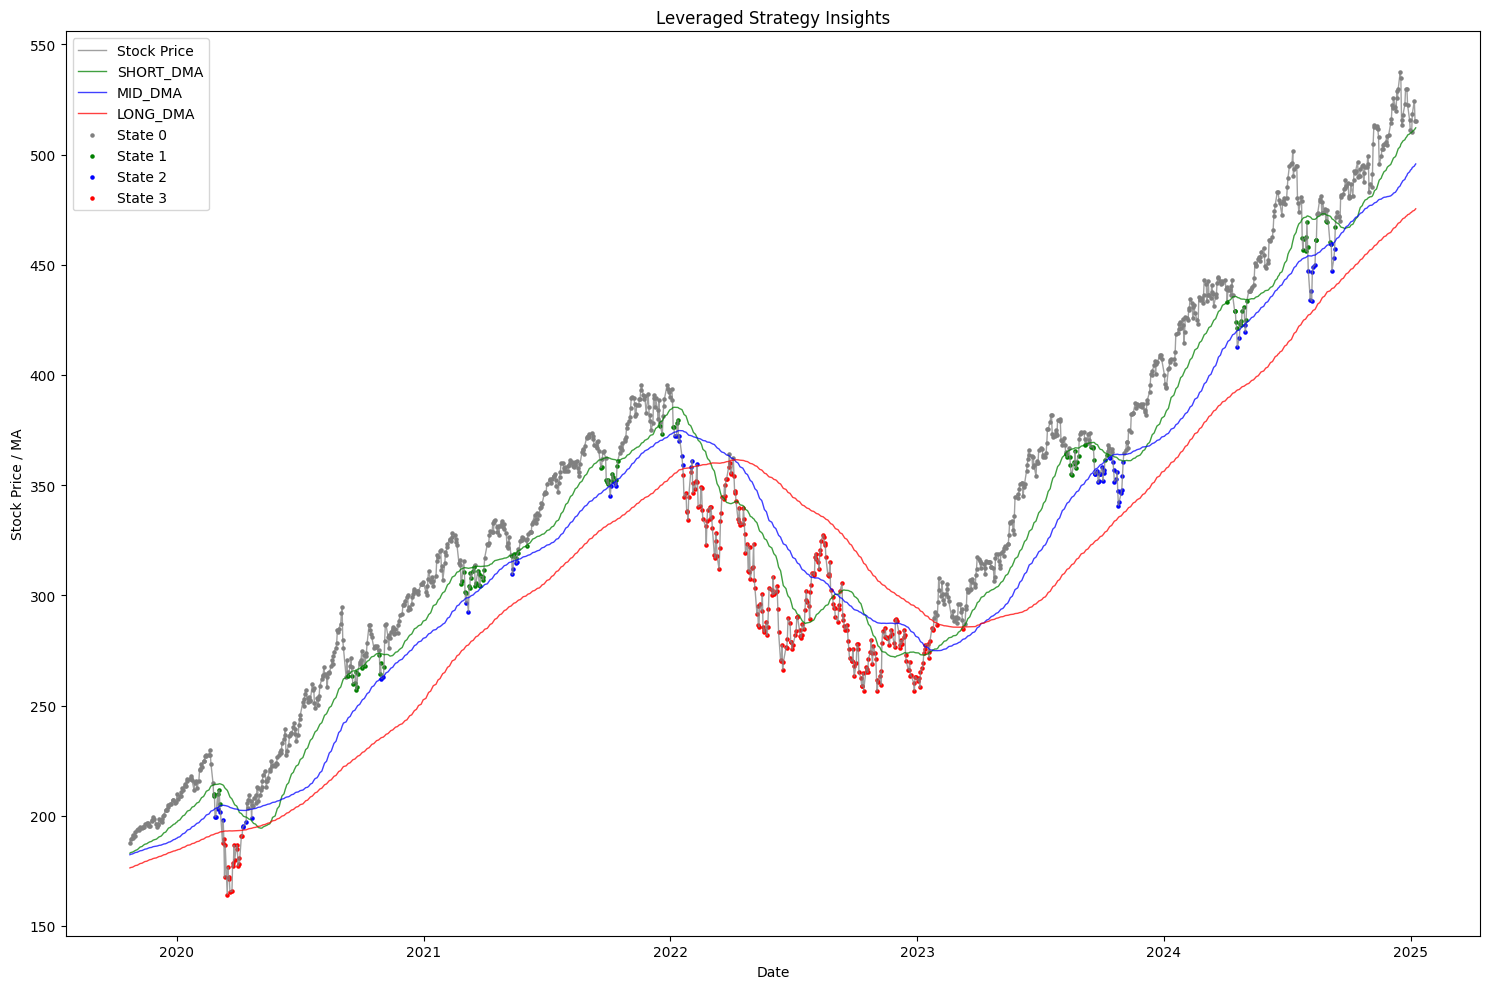

In [43]:
fig_size = (15, 10)
plt.figure(figsize=fig_size)

plt.plot(stock_df.index, stock_df['S_PRICE'], label='Stock Price', color="grey", alpha=0.75, lw=1)
plt.plot(stock_df.index, stock_df['SHORT_DMA'], label='SHORT_DMA', color="green", alpha=0.75, lw=1)
plt.plot(stock_df.index, stock_df['MID_DMA'], label='MID_DMA', color="blue", alpha=0.75, lw=1)
plt.plot(stock_df.index, stock_df['LONG_DMA'], label='LONG_DMA', color="red", alpha=0.75, lw=1)


state_colors = {0: 'grey', 1: 'green', 2: 'blue', 3: 'red'}
for state, color in state_colors.items():
    subset = stock_df[stock_df['STATE'] == state]
    plt.scatter(subset.index, subset['S_PRICE'], color=color, label=f'State {state}', s=5)

plt.xlabel('Date')
plt.ylabel('Stock Price / MA')
plt.title("Leveraged Strategy Insights")
plt.legend()
plt.tight_layout()
plt.show()

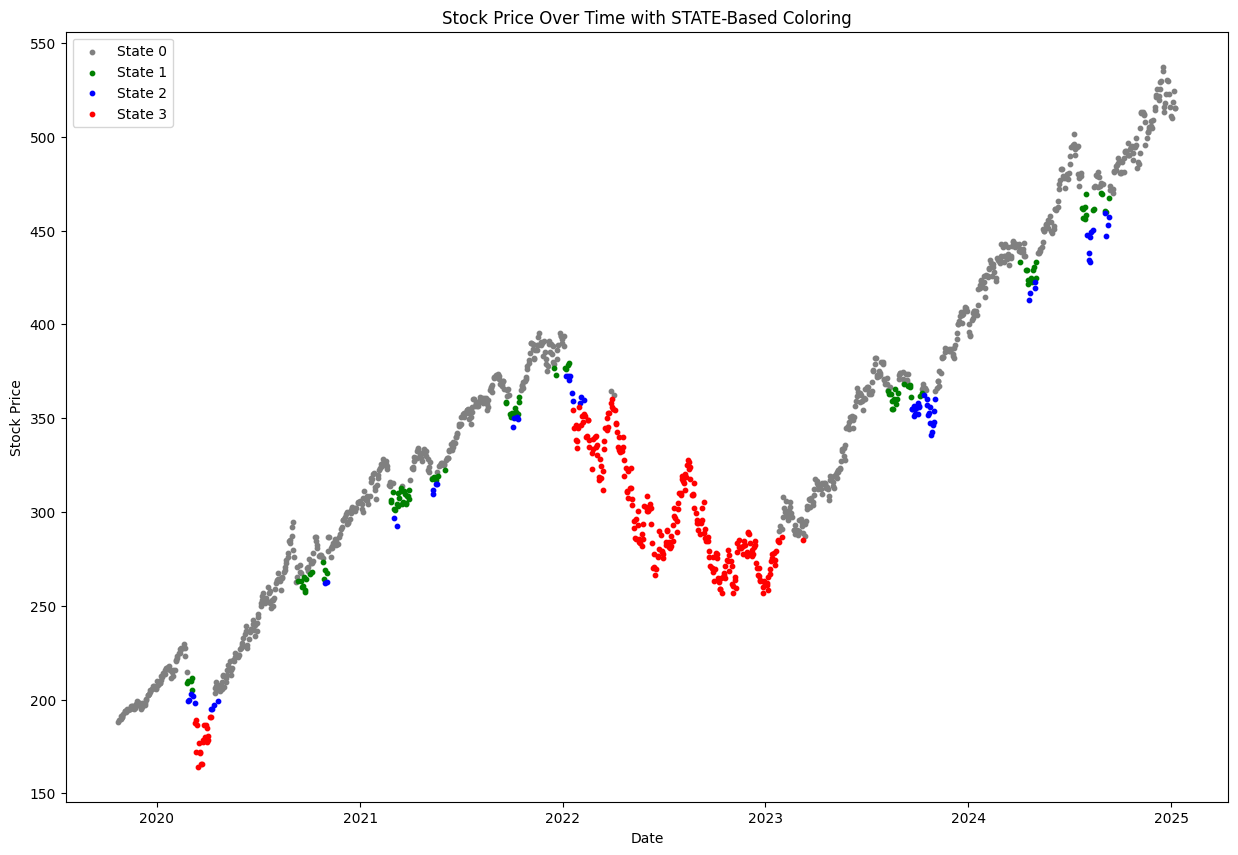

In [42]:
state_colors = {0: 'grey', 1: 'green', 2: 'blue', 3: 'red'}

plt.figure(figsize=(15, 10))

# Iterate through each state and plot separately

for state, color in state_colors.items():
    subset = stock_df[stock_df['STATE'] == state]
    plt.scatter(subset.index, subset['S_PRICE'], color=color, label=f'State {state}', s=10)
    #plt.plot(subset.index, subset['S_PRICE'], color=color, label=f'State {state}')

plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Stock Price Over Time with STATE-Based Coloring')
plt.legend()

In [37]:
#stock_df.round(2).to_csv("Leveraged.csv")